# KardioSense — Step 4B: 12-Lead Expansion

**What this experiment answers:**

Can KardioSense's architecture compete with ISIBrno on its own turf — 12 leads?

Step 3 showed KardioSense beats ISIBrno at every config from 1L to 6L. 
ISIBrno's only remaining advantage is at its native 12-lead (MI AUC=0.935). 
This notebook retrains KardioSense with `n_leads=12`, the same lead-agnostic 
masking strategy extended to all 12 leads, and evaluates on fold 10.

**This also addresses the benchmark bias question from Step 3:** 
By testing KardioSense at 12-lead we remove the "only 6 leads available" constraint 
and put both architectures on equal footing for a clean comparison.

**Architecture change — two parameters only:**
```python
# Before (NB02):
KardioSenseECGModel(n_leads=6, ...)
  stem : Conv1d(6, 32, ...) # 6-channel input
  mask_proj: Linear(6, 32) # 6-dim mask

# After (this notebook):
KardioSenseECGModel(n_leads=12, ...)
  stem : Conv1d(12, 32, ...) # 12-channel input
  mask_proj: Linear(12, 32) # 12-dim mask
```
All ResBlocks, BiLSTM, attention, pooling, classifier — **unchanged**.

**Final comparison table this produces:**

| Model | Config | MI AUC | Macro AUC | 1L MI AUC |
|---|---|---|---|---|
| KS Baseline | 6L | 0.915 | 0.927 | 0.810 |
| KS + CLA | 6L | (Step 4A) | — | — |
| KS 12L | 12L | ? | ? | ? |
| ISIBrno | 6L | 0.848 | 0.895 | 0.327 |
| ISIBrno | 12L | 0.935 | 0.943 | 0.327 |


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
BENCH_DIR = f'{BASE_DIR}/benchmark'

required = {
    'PTB-XL cache' : f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz',
    'KS 6L checkpoint' : f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt',
    'ISIBrno checkpoint' : f'{CKPT_DIR}/isibrno_ptbxl_best_mi.pt',
    'Step 3 ablation results': f'{BENCH_DIR}/results_step3_ablation.json',
    'Step 2 results' : f'{BENCH_DIR}/results_step2.json',
}
# Step 4A results are optional — may not exist yet
step4a_path = f'{BENCH_DIR}/results_step4a.json'

print('Checking required inputs:')
all_ok = True
for name, path in required.items():
    ok = os.path.exists(path)
    print(f' {"" if ok else ""} {name:<28} '
          f'{os.path.getsize(path)/1e6:.1f} MB' if ok else f' {name} MISSING')
    if not ok: all_ok = False
assert all_ok

STEP4A_AVAILABLE = os.path.exists(step4a_path)
print(f'\n {"" if STEP4A_AVAILABLE else "⏭"} Step 4A results: '
      f'{"found — will include in final table" if STEP4A_AVAILABLE else "not found — run 4A first for full table"}')


Mounted at /content/drive
Checking required inputs:
  ✅ PTB-XL cache                  932.9 MB
  ✅ KS 6L checkpoint              36.5 MB
  ✅ ISIBrno checkpoint            26.2 MB
  ✅ Step 3 ablation results       0.0 MB
  ✅ Step 2 results                0.0 MB

  ✅ Step 4A results: found — will include in final table


In [2]:
!pip install -q wfdb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, average_precision_score
import json, time, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL_NAMES = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
ALL_LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
ALL_12_IDX = list(range(12))

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'12-lead config: {ALL_LEADS}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 118.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.4 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.4 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.4 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.4 which is incompatible.
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
12-lead config: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## 1. Load Cache & Splits

In [3]:
cache = np.load(f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz')
X = cache['X']; Y = cache['Y']; ecg_ids = cache['ecg_ids']

df_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')
df_filtered = df_meta.loc[ecg_ids]
train_idx = np.where(df_filtered['strat_fold'].isin(range(1,9)))[0]
val_idx = np.where(df_filtered['strat_fold'] == 9)[0]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]

X_train,Y_train = X[train_idx],Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

labels_ref = np.load(f'{BENCH_DIR}/labels_test_fold10.npy')
assert np.allclose(labels_ref, Y_test)

print(f'Train={len(X_train):,} Val={len(X_val):,} Test={len(X_test):,}')
print(f'Using all 12 leads: {ALL_LEADS}')


Train=3,195  Val=489  Test=499
Using all 12 leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## 2. Architecture: KardioSense 12-Lead

Exactly the same class as NB02's `KardioSenseECGModel`, with `n_leads=12`. 
We define it here explicitly so this notebook is self-contained.

**Weight initialisation note:** We do NOT transfer weights from the 6-lead 
checkpoint. The stem's first Conv1d layer goes from `(32, 6, 15)` to 
`(32, 12, 15)` — shapes are incompatible. The 12-lead model trains from scratch. 
This is the correct approach for a fair architectural comparison.


In [4]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch,out_ch,kernel_size,stride=stride,padding=pad,bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch,out_ch,kernel_size,stride=1,padding=pad,bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch,out_ch,1,stride=stride,bias=False),nn.BatchNorm1d(out_ch)
        ) if (in_ch!=out_ch or stride!=1) else nn.Identity()
    def forward(self, x):
        r = self.skip(x)
        o = F.relu(self.bn1(self.conv1(x)))
        o = self.drop(o)
        return F.relu(self.bn2(self.conv2(o)) + r)

class AttentionPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.a = nn.Linear(d, 1)
    def forward(self, x):
        w = torch.softmax(self.a(x), dim=1)
        return (x * w).sum(dim=1), w.squeeze(-1)

class KardioSenseECGModel(nn.Module):
    """KardioSense ECG model — parametric n_leads. Same as NB02 except n_leads is configurable."""
    def __init__(self, n_leads=12, n_classes=5, dropout=0.3):
        super().__init__()
        self.n_leads = n_leads
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 32, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1))
        self.layer1 = ResBlock1D(32, 64, stride=2, dropout=dropout)
        self.layer2 = ResBlock1D(64, 128, stride=2, dropout=dropout)
        self.layer3 = ResBlock1D(128, 256, stride=2, dropout=dropout)
        self.layer4 = ResBlock1D(256, 256, stride=2, dropout=dropout)
        self.bilstm = nn.LSTM(256, 128, num_layers=2, batch_first=True,
                              bidirectional=True, dropout=dropout)
        self.self_attn = nn.MultiheadAttention(256, 4, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(256)
        self.attn_pool = AttentionPool(256)
        self.mask_proj = nn.Sequential(nn.Linear(n_leads, 32), nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(288, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, n_classes))

    def forward(self, sig, mask):
        x = self.layer4(self.layer3(self.layer2(self.layer1(self.stem(sig)))))
        x = x.permute(0,2,1)
        x, _ = self.bilstm(x)
        ao, _ = self.self_attn(x,x,x)
        x = self.attn_norm(x+ao)
        e, _ = self.attn_pool(x)
        return self.classifier(torch.cat([e, self.mask_proj(mask)], dim=-1)), None


# ── Param count comparison ─────────────────────────────────────────────────
m6 = KardioSenseECGModel(n_leads=6)
m12 = KardioSenseECGModel(n_leads=12)
p6 = sum(p.numel() for p in m6.parameters())
p12 = sum(p.numel() for p in m12.parameters())
print(f'KardioSense 6L params: {p6:,}')
print(f'KardioSense 12L params: {p12:,} (+{p12-p6:,} from stem and mask_proj)')
print(f' Stem delta : +{(12-6)*32*15:,} (extra lead channels × kernel size)')
print(f' MaskProj delta: +{(12-6)*32:,} (extra lead dims × output dim)')
del m6, m12

model_12l = KardioSenseECGModel(n_leads=12, n_classes=5, dropout=0.3).to(DEVICE)
print(f'\n KardioSense 12L instantiated on {DEVICE}')

KardioSense 6L  params: 3,028,710
KardioSense 12L params: 3,031,782  (+3,072 from stem and mask_proj)
  Stem delta    : +2,880  (extra lead channels × kernel size)
  MaskProj delta: +192  (extra lead dims × output dim)

✅ KardioSense 12L instantiated on cuda


## 3. 12-Lead Dataset with Agnostic Masking

Same `LeadAgnosticECGDataset` class as NB02, now with all 12 leads.

**Mask distribution extended to 12 leads:**

| Strategy | Probability | Clinical context |
|---|---|---|
| All 12 leads | 30% | Hospital ECG machine |
| 6 leads (KS config) | 20% | Full KardioSense cable |
| 4 leads | 15% | Partial cable |
| 2 leads | 15% | Lead I + II |
| 1 lead (Lead I) | 20% | Thumb pads only |

Lead I is always included — it's always available from the thumb pads.


In [5]:
class LeadAgnostic12Dataset(Dataset):
    """
    12-lead version of the lead-agnostic dataset.
    Mask distribution extended to cover 1–12 lead configurations.
    Lead I (index 0) is always included in the mask.
    """
    def __init__(self, X, Y, apply_masking=True, augment=False):
        self.X = X; self.Y = Y
        self.apply_masking = apply_masking; self.augment = augment
        self.n_leads = 12

    def __len__(self): return len(self.X)

    def _sample_mask(self):
        strategy = np.random.choice(
            ['all_12','ks_6','four','two','one'],
            p=[0.30, 0.20, 0.15, 0.15, 0.20]
        )
        mask = np.zeros(12, dtype=np.float32)
        if strategy == 'all_12':
            mask[:] = 1.0
        elif strategy == 'ks_6':
            for i in [0,1,2,5,7,9]: mask[i] = 1.0 # I,II,III,aVF,V2,V4
        elif strategy == 'four':
            idx = np.random.choice(12, size=4, replace=False)
            mask[idx] = 1.0; mask[0] = 1.0
        elif strategy == 'two':
            idx = np.random.choice(12, size=2, replace=False)
            mask[idx] = 1.0; mask[0] = 1.0
        elif strategy == 'one':
            mask[0] = 1.0
        return mask

    def _augment(self, x):
        if np.random.rand()<0.5: x=x*np.random.uniform(0.8,1.2)
        if np.random.rand()<0.3: x=x+np.random.randn(*x.shape).astype(np.float32)*0.05
        if np.random.rand()<0.3: x=np.roll(x,np.random.randint(-50,50),axis=-1)
        return x

    def __getitem__(self, idx):
        x = self.X[idx].T.copy().astype(np.float32) # (12, 5000)
        if self.augment: x=self._augment(x)
        mask = self._sample_mask() if self.apply_masking else np.ones(12,dtype=np.float32)
        x = x * mask[:,np.newaxis]
        return (torch.tensor(x), torch.tensor(mask),
                torch.tensor(self.Y[idx].astype(np.float32)))


BATCH_SIZE = 64

train_ds_12 = LeadAgnostic12Dataset(X_train,Y_train,apply_masking=True,augment=True)
val_ds_12 = LeadAgnostic12Dataset(X_val, Y_val, apply_masking=False,augment=False)
test_ds_12 = LeadAgnostic12Dataset(X_test, Y_test, apply_masking=False,augment=False)

mi_labels = Y_train[:,LABEL_NAMES.index('MI')].astype(int)
mi_counts = np.bincount(mi_labels)
mi_weights = 1.0/mi_counts[mi_labels]
sampler_12 = WeightedRandomSampler(torch.DoubleTensor(mi_weights),len(mi_weights),replacement=True)

train_loader_12 = DataLoader(train_ds_12, batch_size=BATCH_SIZE, sampler=sampler_12, num_workers=2, pin_memory=True)
val_loader_12 = DataLoader(val_ds_12, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_12 = DataLoader(test_ds_12, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_pos = Y_train.sum(axis=0)
n_neg = len(Y_train) - n_pos
pos_weight = torch.tensor(n_neg/(n_pos+1e-6),dtype=torch.float32).to(DEVICE)

print(' 12-lead datasets ready')
print(f' Train={len(train_ds_12):,} Val={len(val_ds_12):,} Test={len(test_ds_12):,}')
print(f' Mask distribution: 30% all-12 | 20% KS-6 | 15% four | 15% two | 20% one-lead')

# Verify batch shape
_x,_m,_y = next(iter(train_loader_12))
print(f' Batch: sig={tuple(_x.shape)} mask={tuple(_m.shape)} label={tuple(_y.shape)}')
del _x,_m,_y


✅ 12-lead datasets ready
   Train=3,195  Val=489  Test=499
   Mask distribution: 30% all-12  |  20% KS-6  |  15% four  |  15% two  |  20% one-lead
   Batch: sig=(64, 12, 5000)  mask=(64, 12)  label=(64, 5)


## 4. Train KardioSense 12-Lead

**Training config — identical to NB02 except:**
- `n_leads=12` throughout
- Mask distribution includes 12-lead and KS-6-lead as named strategies
- Checkpoint saved as `kardiosense_12l_best_mi.pt`

Everything else held constant: AdamW lr=5e-4, OneCycleLR, 40 epochs, 
MI-weighted sampler, grad clip 1.0, best-by-val-MI-AUC checkpoint.


In [6]:
def evaluate(model, loader, criterion, device):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for sig,mask,labels in loader:
            sig,mask,labels = sig.to(device),mask.to(device),labels.to(device)
            logits,_ = model(sig,mask)
            total_loss += criterion(logits,labels).item()
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    preds = np.vstack(all_preds); labels = np.vstack(all_labels)
    aucs = {}
    for i,lbl in enumerate(LABEL_NAMES):
        aucs[lbl]=roc_auc_score(labels[:,i],preds[:,i]) if labels[:,i].sum()>0 else float('nan')
    aucs['MACRO'] = float(np.nanmean(list(aucs.values())))
    return total_loss/len(loader), aucs, preds, labels


criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model_12l.parameters(), lr=5e-4, weight_decay=1e-4)
N_EPOCHS = 40
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=5e-4,
    steps_per_epoch=len(train_loader_12),
    epochs=N_EPOCHS, pct_start=0.1)

CKPT_12L = f'{CKPT_DIR}/kardiosense_12l_best_mi.pt'
best_mi = 0.0
history = {'train_loss':[],'val_loss':[],'val_mi_auc':[],'val_macro_auc':[]}

print(f' Training KardioSense 12-Lead — {N_EPOCHS} epochs')
print('─'*78)
print(f' {"Ep":>4} {"TrLoss":>8} {"VaLoss":>8} {"NORM":>7} {"MI":>7} {"STTC":>7} {"CD":>7} {"MACRO":>7}')
print('─'*78)

train_start = time.time()
for epoch in range(1,N_EPOCHS+1):
    model_12l.train(); train_loss=0.0
    for sig,mask,labels in train_loader_12:
        sig,mask,labels = sig.to(DEVICE),mask.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        logits,_ = model_12l(sig,mask)
        loss = criterion(logits,labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model_12l.parameters(),max_norm=1.0)
        optimizer.step(); scheduler.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_12)

    val_loss,val_aucs,_,_ = evaluate(model_12l,val_loader_12,criterion,DEVICE)
    mi_auc = val_aucs.get('MI',0); macro = val_aucs.get('MACRO',0)
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['val_mi_auc'].append(mi_auc); history['val_macro_auc'].append(macro)

    flag=''
    if mi_auc > best_mi:
        best_mi = mi_auc
        torch.save({
            'epoch':int(epoch), 'model_state':model_12l.state_dict(),
            'mi_auc':float(mi_auc), 'macro_auc':float(macro),
            'config':{
                'architecture':'KardioSense-12L','n_leads':12,
                'lead_indices':ALL_12_IDX,'lead_names':ALL_LEADS,
                'n_classes':5,'label_names':LABEL_NAMES,
            }
        }, CKPT_12L)
        flag=' ← best MI'

    print(f' {epoch:>4} {train_loss:>8.4f} {val_loss:>8.4f} '
          f'{val_aucs.get("NORM",0):>7.3f} {mi_auc:>7.3f} '
          f'{val_aucs.get("STTC",0):>7.3f} {val_aucs.get("CD",0):>7.3f} '
          f'{macro:>7.3f}{flag}')

print('─'*78)
print(f' Done in {(time.time()-train_start)/60:.1f} min | Best val MI AUC: {best_mi:.4f}')


🚀 Training KardioSense 12-Lead — 40 epochs
──────────────────────────────────────────────────────────────────────────────
    Ep   TrLoss   VaLoss    NORM      MI    STTC      CD   MACRO
──────────────────────────────────────────────────────────────────────────────
     1   1.2372   2.0917   0.798   0.753   0.710   0.778   0.799  ← 🏆 best MI
     2   1.1176   2.2083   0.951   0.840   0.885   0.835   0.811  ← 🏆 best MI
     3   0.8390   1.2239   0.940   0.856   0.886   0.834   0.903  ← 🏆 best MI
     4   0.9272   1.2957   0.951   0.866   0.900   0.840   0.895  ← 🏆 best MI
     5   0.8084   4.1116   0.955   0.822   0.900   0.888   0.817
     6   0.8705   0.8268   0.966   0.872   0.905   0.890   0.924  ← 🏆 best MI
     7   0.7044   1.2453   0.968   0.896   0.912   0.901   0.920  ← 🏆 best MI
     8   0.8156   1.6165   0.965   0.884   0.893   0.906   0.922
     9   0.5812   1.1946   0.955   0.888   0.894   0.882   0.922
    10   0.5968   1.1139   0.966   0.899   0.895   0.904   0.931  ← 🏆 b

## 5. Test Set Evaluation — All Lead Configs

In [7]:
ckpt_12l = torch.load(CKPT_12L, map_location=DEVICE, weights_only=True)
model_12l.load_state_dict(ckpt_12l['model_state'])
model_12l.eval()
print(f' 12L checkpoint: epoch={ckpt_12l["epoch"]} val MI AUC={ckpt_12l["mi_auc"]:.4f}')

# ── 12-lead test (native config) ──────────────────────────────────────────
_,test_aucs_12l,preds_12l,_ = evaluate(model_12l, test_loader_12, criterion, DEVICE)
np.save(f'{BENCH_DIR}/preds_ks12l_fold10.npy', preds_12l)

# ── 6-lead test (KS config, zeroing other leads) ──────────────────────────
def infer_subset(model, X_np, Y_np, active_ptbxl_idx, n_leads=12, batch_size=128, device=DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    mask_fixed = torch.zeros(n_leads, dtype=torch.float32)
    for i in active_ptbxl_idx: mask_fixed[i] = 1.0
    for i in range(0, len(X_np), batch_size):
        xb = X_np[i:i+batch_size]
        sig = torch.tensor(xb.transpose(0,2,1).astype(np.float32)).to(device)
        sig = sig * mask_fixed.to(device).view(1,n_leads,1)
        msk = mask_fixed.unsqueeze(0).expand(len(xb),-1).to(device)
        with torch.no_grad():
            logits,_ = model(sig,msk)
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(Y_np[i:i+batch_size])
    preds = np.vstack(all_preds); labels = np.vstack(all_labels)
    return {lbl: roc_auc_score(labels[:,i],preds[:,i])
            for i,lbl in enumerate(LABEL_NAMES) if labels[:,i].sum()>0}

KS_6L_IDX = [0,1,2,5,7,9] # I,II,III,aVF,V2,V4

aucs_12l_at_6l = infer_subset(model_12l, X_test, Y_test, KS_6L_IDX)
aucs_12l_at_6l['MACRO'] = float(np.nanmean(list(aucs_12l_at_6l.values())))

aucs_12l_at_1l = infer_subset(model_12l, X_test, Y_test, [0])
aucs_12l_at_1l['MACRO'] = float(np.nanmean(list(aucs_12l_at_1l.values())))

# ── Load comparison results ────────────────────────────────────────────────
with open(f'{BENCH_DIR}/results_step3_ablation.json') as f:
    step3 = json.load(f)
with open(f'{BENCH_DIR}/results_step2.json') as f:
    step2 = json.load(f)

ks6l_12l_ref = step3['results']['12L']['ib'] # ISIBrno 12L
ks6l_6l_ref = step3['results']['6L']['ks'] # KS 6L baseline
ib_6l_ref = step3['results']['6L']['ib'] # ISIBrno 6L

def get_auc(d, lbl):
    v = d.get(lbl, {})
    if isinstance(v, dict): return v.get('auc', float('nan'))
    return float('nan')

print()
print('='*85)
print('FINAL BENCHMARK — All Models | PTB-XL fold 10')
print('='*85)
print(f' {"Model":<22} {"Config":<8} {"NORM":>7} {"MI":>7} {"STTC":>7} {"CD":>7} {"MACRO":>7}')
print(' ' + '─'*73)

rows = [
    ('KS Baseline', '6L', {lbl: get_auc(ks6l_6l_ref, lbl) for lbl in LABEL_NAMES+['MACRO']}),
    ('KS 12L (12L)', '12L', {**{lbl: test_aucs_12l.get(lbl,float('nan')) for lbl in LABEL_NAMES}, 'MACRO': test_aucs_12l.get('MACRO',float('nan'))}),
    ('KS 12L (6L)', '6L', {**aucs_12l_at_6l}),
    ('KS 12L (1L)', '1L', {**aucs_12l_at_1l}),
    ('ISIBrno', '6L', {lbl: get_auc(ib_6l_ref, lbl) for lbl in LABEL_NAMES+['MACRO']}),
    ('ISIBrno', '12L', {lbl: get_auc(ks6l_12l_ref, lbl) for lbl in LABEL_NAMES+['MACRO']}),
]

for name,cfg,aucs in rows:
    vals = ' '.join(f'{aucs.get(lbl,float("nan")):>7.4f}' for lbl in ['NORM','MI','STTC','CD','MACRO'])
    print(f' {name:<22} {cfg:<8} {vals}')

# Add Step 4A if available
if STEP4A_AVAILABLE:
    with open(f'{BENCH_DIR}/results_step4a.json') as f:
        step4a = json.load(f)
    cla_aucs = {lbl: step4a['test_6lead']['ks_cla'].get(lbl,{}).get('auc',float('nan'))
                for lbl in LABEL_NAMES+['MACRO']}
    vals = ' '.join(f'{cla_aucs.get(lbl,float("nan")):>7.4f}' for lbl in ['NORM','MI','STTC','CD','MACRO'])
    print(f' {"KS + CLA":<22} {"6L":<8} {vals}')

print('='*85)


✅ 12L checkpoint: epoch=22  val MI AUC=0.9261

FINAL BENCHMARK — All Models  |  PTB-XL fold 10
  Model                   Config       NORM       MI     STTC       CD    MACRO
  ─────────────────────────────────────────────────────────────────────────
  KS Baseline             6L         0.9284   0.9149   0.9154   0.8794   0.9274
  KS 12L (12L)            12L        0.9513   0.9187   0.9036   0.8978   0.9343
  KS 12L (6L)             6L         0.9444   0.9038   0.8998   0.8749   0.9246
  KS 12L (1L)             1L         0.8945   0.8145   0.8645   0.7643   0.8674
  ISIBrno                 6L         0.9186   0.8480   0.9133   0.7962   0.8950
  ISIBrno                 12L        0.9496   0.9351   0.9373   0.8916   0.9427
  KS + CLA                6L         0.9354   0.9093   0.8978   0.8624   0.9210


## 6. Robustness: KS 12L vs KS 6L vs ISIBrno at 1-lead

The key question: does the 12L model maintain the robustness advantage at 1-lead, 
or does learning from 12 leads make it reliant on having more leads available?


In [8]:
# Sweep KS-12L across all ablation configs
ABLATION_CONFIGS_12L = {
    '1L' : [0],
    '2L' : [0,1],
    '3L' : [0,1,5],
    '6L' : [0,1,2,5,7,9],
    '12L': list(range(12)),
}

ks12l_ablation = {}
print('KS 12L — Lead ablation sweep:')
for short, idx in ABLATION_CONFIGS_12L.items():
    aucs = infer_subset(model_12l, X_test, Y_test, idx)
    aucs['MACRO'] = float(np.nanmean(list(aucs.values())))
    ks12l_ablation[short] = aucs
    print(f' {short}: MI AUC={aucs.get("MI",float("nan")):.4f} Macro={aucs["MACRO"]:.4f}')

# Compare 1-lead robustness
print()
print('1-Lead MI AUC Comparison:')
ks6l_1l = get_auc(step3['results']['1L']['ks'], 'MI')
ib_1l = get_auc(step3['results']['1L']['ib'], 'MI')
ks12l_1l = ks12l_ablation['1L'].get('MI', float('nan'))
print(f' KS 6L baseline : {ks6l_1l:.4f}')
print(f' KS 12L (this) : {ks12l_1l:.4f}')
print(f' ISIBrno : {ib_1l:.4f}')
print()
print('6-Lead → 1-Lead MI AUC Drop:')
ks6l_6l_auc = get_auc(step3['results']['6L']['ks'], 'MI')
ks12l_6l_auc = ks12l_ablation['6L'].get('MI', float('nan'))
print(f' KS 6L drop: {ks6l_6l_auc:.4f} → {ks6l_1l:.4f} Δ={ks6l_1l-ks6l_6l_auc:+.4f} ({(ks6l_6l_auc-ks6l_1l)/ks6l_6l_auc*100:.1f}%)')
print(f' KS 12L drop: {ks12l_6l_auc:.4f} → {ks12l_1l:.4f} Δ={ks12l_1l-ks12l_6l_auc:+.4f} ({(ks12l_6l_auc-ks12l_1l)/ks12l_6l_auc*100:.1f}%)')
print(f' ISIBrno drop: {get_auc(step3["results"]["6L"]["ib"],"MI"):.4f} → {ib_1l:.4f} (Step 3: 61.5% drop)')


KS 12L — Lead ablation sweep:
  1L: MI AUC=0.8145  Macro=0.8674
  2L: MI AUC=0.8422  Macro=0.8962
  3L: MI AUC=0.8433  Macro=0.9001
  6L: MI AUC=0.9038  Macro=0.9246
  12L: MI AUC=0.9187  Macro=0.9343

1-Lead MI AUC Comparison:
  KS 6L  baseline  : 0.8101
  KS 12L (this)    : 0.8145
  ISIBrno          : 0.3269

6-Lead → 1-Lead MI AUC Drop:
  KS 6L   drop: 0.9149 → 0.8101   Δ=-0.1048  (11.5%)
  KS 12L  drop: 0.9038 → 0.8145   Δ=-0.0893  (9.9%)
  ISIBrno drop: 0.8480 → 0.3269   (Step 3: 61.5% drop)


## 7. Final Benchmark Visualisation

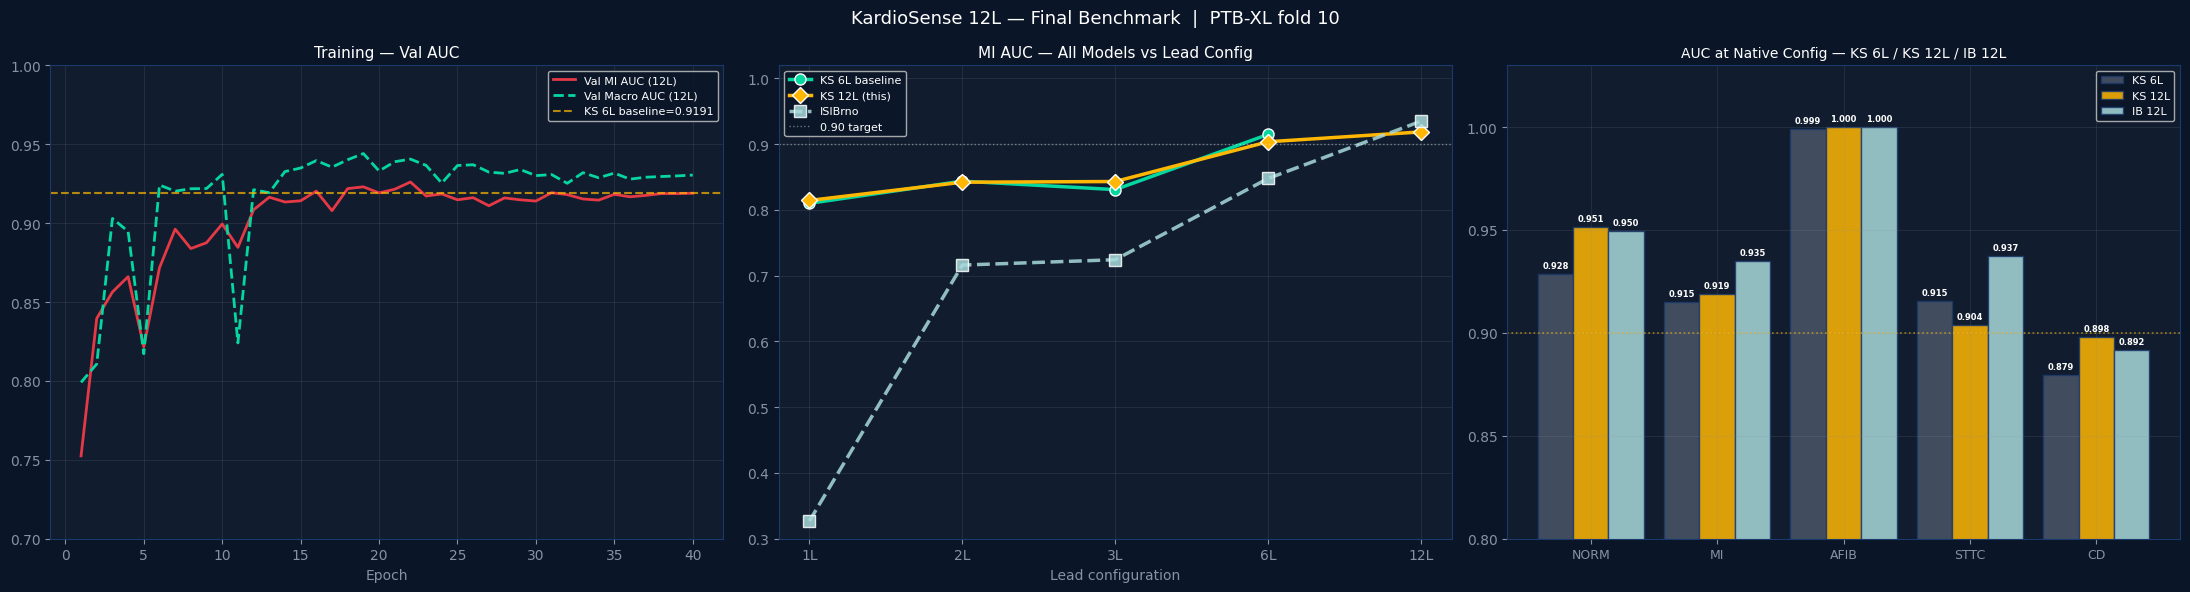

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/step4b_12l_results.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor='#0A1628')
fig.suptitle('KardioSense 12L — Final Benchmark | PTB-XL fold 10',
             color='white', fontsize=13)

for ax in axes:
    ax.set_facecolor('#111D2E')
    for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
    ax.tick_params(colors='#8892A4')
    ax.grid(True, alpha=0.15, color='#8892A4')

# ── Left: Training curve ───────────────────────────────────────────────────
ax = axes[0]
epochs = range(1, N_EPOCHS+1)
ax.plot(epochs, history['val_mi_auc'], color='#E63946', lw=2, label='Val MI AUC (12L)')
ax.plot(epochs, history['val_macro_auc'], color='#06D6A0', lw=2, label='Val Macro AUC (12L)', ls='--')
ckpt_base = torch.load(f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt', map_location='cpu', weights_only=True)
ax.axhline(ckpt_base['mi_auc'], color='#FFB703', lw=1.5, ls='--', alpha=0.7,
           label=f'KS 6L baseline={ckpt_base["mi_auc"]:.4f}')
ax.set_title('Training — Val AUC', color='white', fontsize=11)
ax.set_xlabel('Epoch', color='#8892A4'); ax.set_ylim(0.7, 1.0)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Middle: MI AUC lead ablation — all models ─────────────────────────────
ax = axes[1]
config_pts = ['1L','2L','3L','6L','12L']
x_pos = np.arange(len(config_pts))

ks6l_mi = [get_auc(step3['results'][s]['ks'],'MI') if step3['results'][s]['ks'] else np.nan
             for s in config_pts]
ib_mi = [get_auc(step3['results'][s]['ib'],'MI') for s in config_pts]
ks12l_mi = [ks12l_ablation.get(s,{}).get('MI',np.nan) for s in config_pts]

# mask out NaN for plotting
def plot_line(ax, x, y, **kw):
    x_valid = [xi for xi,yi in zip(x,y) if not np.isnan(yi)]
    y_valid = [yi for yi in y if not np.isnan(yi)]
    ax.plot(x_valid, y_valid, **kw)

plot_line(ax, x_pos, ks6l_mi, color='#06D6A0', lw=2.5, marker='o', ms=8,
          markeredgecolor='white', label='KS 6L baseline', ls='-')
plot_line(ax, x_pos, ks12l_mi, color='#FFB703', lw=2.5, marker='D', ms=8,
          markeredgecolor='white', label='KS 12L (this)', ls='-')
plot_line(ax, x_pos, ib_mi, color='#A8DADC', lw=2.5, marker='s', ms=8,
          markeredgecolor='white', label='ISIBrno', ls='--', alpha=0.85)

ax.axhline(0.90, color='white', lw=1.0, ls=':', alpha=0.4, label='0.90 target')
ax.set_xticks(x_pos); ax.set_xticklabels(config_pts, color='#8892A4')
ax.set_ylim(0.30, 1.02)
ax.set_title('MI AUC — All Models vs Lead Config', color='white', fontsize=11)
ax.set_xlabel('Lead configuration', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Right: Final AUC comparison at 12-lead ────────────────────────────────
ax = axes[2]
cls_labels = LABEL_NAMES
x = np.arange(len(cls_labels)); w = 0.28

ks6l_aucs = [get_auc(step3['results']['6L']['ks'], lbl) for lbl in cls_labels]
ks12l_aucs = [test_aucs_12l.get(lbl, np.nan) for lbl in cls_labels]
ib12l_aucs = [get_auc(step3['results']['12L']['ib'], lbl) for lbl in cls_labels]

b1 = ax.bar(x-w, ks6l_aucs, w, label='KS 6L', color='#4A5568', alpha=0.85, edgecolor='#1B3A6B')
b2 = ax.bar(x, ks12l_aucs, w, label='KS 12L', color='#FFB703', alpha=0.85, edgecolor='#1B3A6B')
b3 = ax.bar(x+w, ib12l_aucs, w, label='IB 12L', color='#A8DADC', alpha=0.85, edgecolor='#1B3A6B')

for bars,vals in [(b1,ks6l_aucs),(b2,ks12l_aucs),(b3,ib12l_aucs)]:
    for bar,v in zip(bars,vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}',
                    ha='center', color='white', fontsize=6, fontweight='bold')

ax.axhline(0.90, color='#FFB703', lw=1.2, ls=':', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(cls_labels, color='#8892A4', fontsize=9)
ax.set_ylim(0.80, 1.03)
ax.set_title('AUC at Native Config — KS 6L / KS 12L / IB 12L', color='white', fontsize=10)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/step4b_12l_results.png', dpi=130,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/step4b_12l_results.png')


## 8. Save Results & Final Summary

In [10]:
def s(v):
    if isinstance(v,(float,np.floating)): return None if np.isnan(v) else float(v)
    if isinstance(v,(int,np.integer)): return int(v)
    if isinstance(v,dict): return {k:s(vv) for k,vv in v.items()}
    return v

results_4b = {
    'meta':{
        'experiment' :'Step4B_12LeadExpansion',
        'dataset' :'PTB-XL','test_fold':10,
        'label_names' :LABEL_NAMES,
        'best_val_mi_auc':float(best_mi),
        'training_epochs':N_EPOCHS,
    },
    'ks_12l_at_12lead': s({lbl:{'auc':test_aucs_12l.get(lbl,float('nan'))} for lbl in LABEL_NAMES+['MACRO']}),
    'ks_12l_at_6lead' : s({lbl:{'auc':aucs_12l_at_6l.get(lbl,float('nan'))} for lbl in LABEL_NAMES+['MACRO']}),
    'ks_12l_at_1lead' : s({lbl:{'auc':aucs_12l_at_1l.get(lbl,float('nan'))} for lbl in LABEL_NAMES+['MACRO']}),
    'lead_ablation' : s(ks12l_ablation),
}

out = f'{BENCH_DIR}/results_step4b.json'
with open(out,'w') as f: json.dump(results_4b,f,indent=2)
print(f' Saved → {out}')
print()

# ── Final narrative summary ───────────────────────────────────────────────
ks12_mi_12l = test_aucs_12l.get('MI', float('nan'))
ks12_mi_1l = ks12l_ablation['1L'].get('MI', float('nan'))
ib_mi_12l = get_auc(step3['results']['12L']['ib'],'MI')
ib_mi_1l = get_auc(step3['results']['1L']['ib'],'MI')

print('SUMMARY')
print('='*60)
print(f'KS 12L MI AUC @ 12-lead : {ks12_mi_12l:.4f} (vs ISIBrno {ib_mi_12l:.4f})')
print(f'KS 12L MI AUC @ 1-lead : {ks12_mi_1l:.4f} (vs ISIBrno {ib_mi_1l:.4f})')
print()
if ks12_mi_12l > ib_mi_12l:
    print(' KS 12L EXCEEDS ISIBrno at native 12-lead configuration.')
elif abs(ks12_mi_12l - ib_mi_12l) < 0.01:
    print('≈ KS 12L MATCHES ISIBrno at 12-lead (within 0.01 AUC).')
else:
    print(f' KS 12L trails ISIBrno at 12-lead by {ib_mi_12l-ks12_mi_12l:.4f} AUC.')
print()
if ks12_mi_1l > 0.80:
    print(f' KS 12L MAINTAINS robustness at 1-lead: {ks12_mi_1l:.4f}')
else:
    print(f' KS 12L robustness at 1-lead: {ks12_mi_1l:.4f} — check mask distribution')
print('='*60)


✅ Saved → /content/drive/MyDrive/KardioSenseAI/benchmark/results_step4b.json

SUMMARY
KS 12L  MI AUC @ 12-lead : 0.9187  (vs ISIBrno 0.9351)
KS 12L  MI AUC @ 1-lead  : 0.8145  (vs ISIBrno 0.3269)

⚠️ KS 12L trails ISIBrno at 12-lead by 0.0163 AUC.

✅ KS 12L MAINTAINS robustness at 1-lead: 0.8145
